## 1. Load and look at the raw data

In [3]:
import pandas as pd

df = pd.read_csv('train_FD001.txt', sep='\s+', header=None)

print(df.head(10))   # show first 10 rows
print(df.shape)      # show (rows, columns)

# What we see: 10 rows of numbers, shape (20631, 26)
# What 20631 means: 100 engines × average ~206 cycles each = 20631 rows total
# What 26 means: 2 (engine_id, cycle) + 3 (op settings) + 21 (sensors) = 26 columns

   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   
5   1   6 -0.0043 -0.0001  100.0  518.67  642.10  1584.47  1398.37  14.62   
6   1   7  0.0010  0.0001  100.0  518.67  642.48  1592.32  1397.77  14.62   
7   1   8 -0.0034  0.0003  100.0  518.67  642.56  1582.96  1400.97  14.62   
8   1   9  0.0008  0.0001  100.0  518.67  642.12  1590.98  1394.80  14.62   
9   1  10 -0.0033  0.0001  100.0  518.67  641.71  1591.24  1400.46  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
1 

## 2. NAme the columns

In [4]:
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

df.columns = columns

print(df.head())
print(df.shape)

   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8.4195       0.03        392

## 3. Compute RUL (Remaining Useful Life)

The raw data doesn't have the answer (label) built in. We have to create it ourselves.

In [14]:
# Step 1: Find how many cycles each engine lasted in total
# groupby('engine_id') groups all rows for the same engine together
# ['cycle'].max() finds the highest cycle number = last cycle before failure

max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

print("How long each engine lasted:")
print(max_cycles.head(10)) # doing for ther 10

How long each engine lasted:
   engine_id  max_cycle
0          1        192
1          2        287
2          3        179
3          4        189
4          5        269
5          6        188
6          7        259
7          8        150
8          9        201
9         10        222


In [22]:
# Step 2: Merge this back into main dataframe
df = df.merge(max_cycles, on='engine_id')

# Step 3: Compute RUL for every single row
# RUL = how many cycles left from THIS moment until engine fails
# If engine lasts 192 cycles total and we're at cycle 50:
# RUL = 192 - 50 = 142 cycles remaining
df['RUL'] = df['max_cycle'] - df['cycle']

In [18]:
print(df[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(100))

    engine_id  cycle  max_cycle  RUL
0           1      1        192  191
1           1      2        192  190
2           1      3        192  189
3           1      4        192  188
4           1      5        192  187
..        ...    ...        ...  ...
95          1     96        192   96
96          1     97        192   95
97          1     98        192   94
98          1     99        192   93
99          1    100        192   92

[100 rows x 4 columns]


 ## 4. Create the binary label

We don't want to predict the exact RUL number. We want to answer: "is failure coming soon - yes or no?"
We define "soon" as: RUL ≤ 30 cycles.

OUTPUT : This imbalance (more healthy than failing) is normal and expected. It means accuracy alone is a bad metric - we'll use AUC-ROC instead.

In [19]:
# If less than 30 cycles remain → engine is in danger → label = 1
# If more than 30 cycles remain → engine is fine → label = 0
df['label'] = (df['RUL'] <= 30).astype(int)

# Check how many failure vs healthy rows we have
print("Label distribution:")
print(df['label'].value_counts())
print(f"\nFailure rate: {df['label'].mean():.1%}")

Label distribution:
label
0    17531
1     3100
Name: count, dtype: int64

Failure rate: 15.0%


## 5. Look at one engine over time

Before building any model, look at the data visually. Does sensor data actually change as the engine approaches failure?

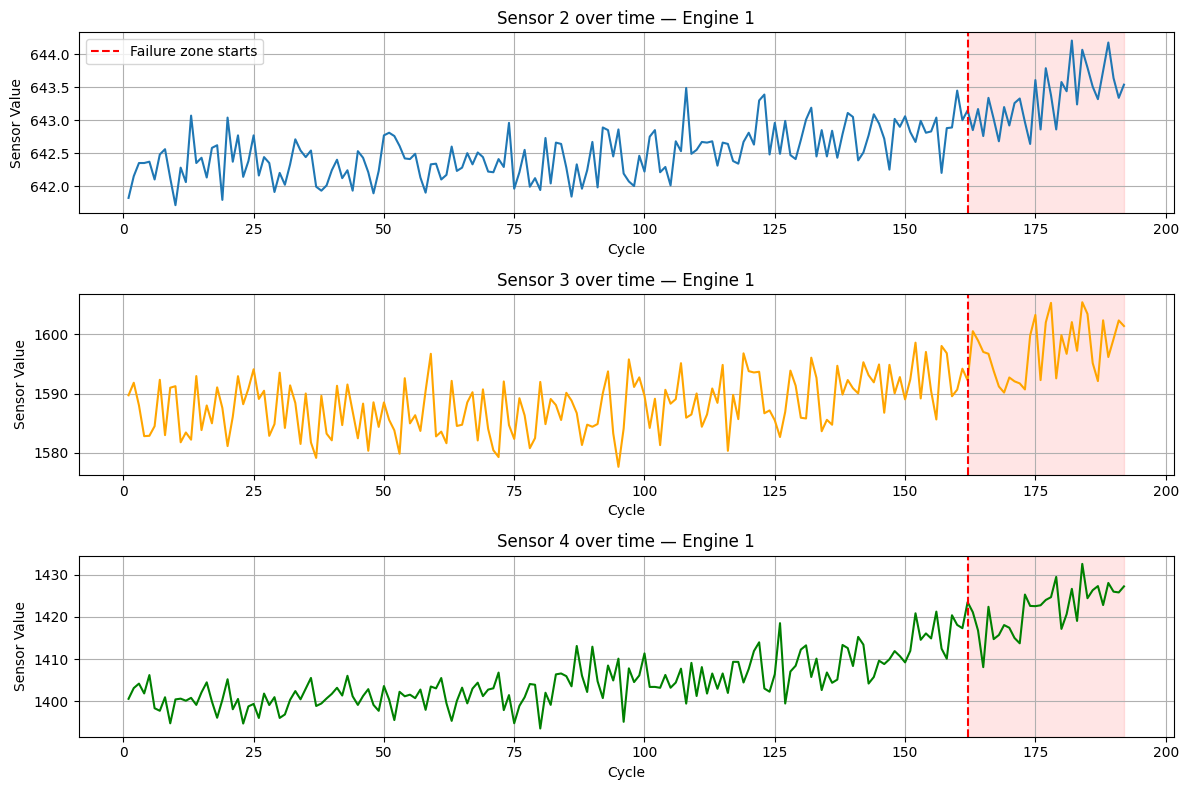

In [23]:
import matplotlib.pyplot as plt

# Step 1: Filter one engine
engine_1 = df[df['engine_id'] == 1]

# Step 2: Calculate failure start (last 30 cycles)
failure_start = engine_1['max_cycle'].iloc[0] - 30

# Step 3: Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Step 4: Plot sensors
axes[0].plot(engine_1['cycle'], engine_1['sensor_2'])
axes[0].set_title('Sensor 2 over time — Engine 1')

axes[1].plot(engine_1['cycle'], engine_1['sensor_3'], color='orange')
axes[1].set_title('Sensor 3 over time — Engine 1')

axes[2].plot(engine_1['cycle'], engine_1['sensor_4'], color='green')
axes[2].set_title('Sensor 4 over time — Engine 1')

# Step 5: Add failure line + shaded zone to ALL plots
for ax in axes:
    ax.axvline(x=failure_start, color='red', linestyle='--', label='Failure zone starts')
    ax.axvspan(failure_start, engine_1['cycle'].max(), color='red', alpha=0.1)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Sensor Value')
    ax.grid(True)

# Show legend only once (clean look)
axes[0].legend()

# Step 6: Adjust layout and show
plt.tight_layout()
plt.show()

## 6. Find which sensors are actually useful

In [24]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]

# nunique() counts how many different values each column has
# A sensor with nunique = 1 is constant — useless
unique_counts = df[sensor_cols].nunique()
print("Unique values per sensor:")
print(unique_counts)

# Keep only sensors that actually change (more than 2 unique values)
useful_sensors = unique_counts[unique_counts > 2].index.tolist()
print(f"\nUseful sensors: {useful_sensors}")
print(f"Dropped sensors: {[s for s in sensor_cols if s not in useful_sensors]}")

Unique values per sensor:
sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
dtype: int64

Useful sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Dropped sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


 ## 7. Normalize the sensor values

In [25]:
from sklearn.preprocessing import MinMaxScaler

# NOW we define sensor_cols properly — only the useful ones
sensor_cols = useful_sensors  # from the previous cell

scaler = MinMaxScaler()

# fit_transform learns the min/max of each sensor
# then scales every value to be between 0 and 1
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

print("After normalization:")
print(df[sensor_cols].describe().round(3))
# All min values should be 0.0, all max values should be 1.0

After normalization:
        sensor_2   sensor_3   sensor_4   sensor_7   sensor_8   sensor_9  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.443      0.425      0.450      0.566      0.298      0.195   
std        0.151      0.134      0.152      0.143      0.108      0.099   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        0.336      0.332      0.339      0.477      0.227      0.141   
50%        0.431      0.416      0.435      0.578      0.288      0.175   
75%        0.539      0.509      0.545      0.670      0.364      0.214   
max        1.000      1.000      1.000      1.000      1.000      1.000   

       sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.411      0.581      0.318      0.226      0.451      0.434   
std        0.159      0.157      0.106      0.098      0.144      0.129   
min

## 8. Create sliding windows
A neural network needs to look at a sequence of cycles to detect patterns. Not just "what is sensor_3 right now" but "how has sensor_3 been changing over the last 30 cycles?"
We slide a window of 30 cycles across each engine's history.

In [26]:
import numpy as np

def create_windows(dataframe, sensor_columns, window_size=30):
    """
    Takes the full dataframe and creates sliding windows.
    
    For each engine:
        Window 1 = cycles 1 to 30
        Window 2 = cycles 2 to 31  
        Window 3 = cycles 3 to 32
        ... and so on
    
    Each window becomes ONE training sample.
    The label for that window = the label at the LAST cycle in the window.
    """
    X = []  # will hold all the windows
    y = []  # will hold all the labels
    
    for engine_id in dataframe['engine_id'].unique():
        # Get all rows for this engine, in order
        engine_data = dataframe[dataframe['engine_id'] == engine_id].sort_values('cycle')
        
        sensor_values = engine_data[sensor_columns].values  # shape: (n_cycles, n_sensors)
        labels = engine_data['label'].values                # shape: (n_cycles,)
        
        # Slide the window
        for i in range(len(engine_data) - window_size + 1):
            window = sensor_values[i : i + window_size]    # shape: (30, n_sensors)
            label = labels[i + window_size - 1]            # label at end of window
            X.append(window)
            y.append(label)
    
    X = np.array(X)  # shape: (total_windows, 30, n_sensors)
    y = np.array(y)  # shape: (total_windows,)
    
    return X, y

# Create the windows
X, y = create_windows(df, sensor_cols, window_size=30)

print(f"X shape: {X.shape}")
# Should be something like (17000, 30, 14)
# 17000 windows, each 30 cycles long, each with 14 sensors

print(f"y shape: {y.shape}")
print(f"Failure rate in windows: {y.mean():.1%}")

X shape: (17731, 30, 14)
y shape: (17731,)
Failure rate in windows: 17.5%


## 9. Split into train and validation sets

In [27]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for validation
# stratify=y means keep the same failure ratio in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Training failure rate:   {y_train.mean():.1%}")
print(f"Validation failure rate: {y_val.mean():.1%}")

Training samples:   14184
Validation samples: 3547
Training failure rate:   17.5%
Validation failure rate: 17.5%


 ## 10. Build the CNN model

In [28]:
import torch
import torch.nn as nn

class CNN1D(nn.Module):
    """
    A 1D Convolutional Neural Network for time series classification.
    
    Input:  (batch_size, n_sensors, seq_length) = (batch, 14, 30)
    Output: (batch_size, 2) = probability of [healthy, failing]
    
    How it works:
        Conv1 looks for short patterns (3 cycles long)
        Conv2 looks for longer patterns built from Conv1's features
        GlobalAvgPool compresses the time dimension
        Linear layer makes the final healthy/failing decision
    """
    def __init__(self, n_sensors=14, seq_length=30):
        super(CNN1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=n_sensors, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)  # compress to 1 value per channel
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 2)           # 64 features → 2 classes
    
    def forward(self, x):
        # x shape coming in: (batch, seq_length, n_sensors)
        # Conv1d expects: (batch, n_sensors, seq_length) — swap axes
        x = x.permute(0, 2, 1)
        
        x = self.relu(self.conv1(x))   # (batch, 32, 30)
        x = self.relu(self.conv2(x))   # (batch, 64, 30)
        x = self.pool(x)               # (batch, 64, 1)
        x = x.squeeze(-1)              # (batch, 64)
        x = self.dropout(x)
        x = self.fc(x)                 # (batch, 2)
        return x

# Create the model
n_sensors = len(sensor_cols)
model = CNN1D(n_sensors=n_sensors, seq_length=30)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

CNN1D(
  (conv1): Conv1d(14, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 7,714


## 11. Train the model

In [35]:
from sklearn.metrics import roc_auc_score

# 1. Prepare Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)

# 2. Setup Model & Weighted Loss
# We give class 1 (failure) 5x more importance because it is rare
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN1D(n_sensors=len(sensor_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

weights = torch.tensor([1.0, 5.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# 3. Training Loop
EPOCHS = 100 
best_auc = 0.0

print(f"{'Epoch':>5} {'Loss':>8} {'Accuracy':>10} {'AUC-ROC':>10}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    
    # Move data to device
    inputs, labels = X_train_t.to(device), y_train_t.to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_inputs = X_val_t.to(device)
        val_outputs = model(val_inputs)
        probs = torch.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()
        
        # Use 0.4 threshold to be more sensitive to failures
        preds = (probs > 0.4).astype(int)
        accuracy = (preds == y_val).mean()
        auc = roc_auc_score(y_val, probs)
        
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), 'best_model.pt')
            
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch: >5} {loss.item(): >8.4f} {accuracy: >10.1%} {auc: >10.4f}")

print(f"\nTraining Complete! Best AUC: {best_auc:.4f}")

Epoch     Loss   Accuracy    AUC-ROC
----------------------------------------
    1   0.6950      17.5%     0.8524
    5   0.6799      17.5%     0.9210
   10   0.6616      17.5%     0.9404
   15   0.6317      19.0%     0.9517
   20   0.5850      48.1%     0.9595
   25   0.5246      65.4%     0.9616
   30   0.4563      76.3%     0.9627
   35   0.3845      80.4%     0.9636
   40   0.3169      83.9%     0.9648
   45   0.2730      85.7%     0.9660
   50   0.2440      87.3%     0.9671
   55   0.2267      87.9%     0.9680
   60   0.2179      88.3%     0.9687
   65   0.2156      88.5%     0.9691
   70   0.2161      88.7%     0.9693
   75   0.2129      88.8%     0.9695
   80   0.2142      88.9%     0.9694
   85   0.2133      88.8%     0.9694
   90   0.2094      88.8%     0.9695
   95   0.2100      88.7%     0.9695
  100   0.2111      88.7%     0.9696

Training Complete! Best AUC: 0.9696


## 12. Understanding THE results

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

# 1. Load the best saved model
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    val_inputs = X_val_t.to(device)
    val_outputs = model(val_inputs)
    # Get raw probabilities for the failure class
    probs = torch.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()

# 2. Find the best threshold automatically
# This looks at the trade-off between catching failures and false alarms
precision, recall, thresholds = precision_recall_curve(y_val, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

# 3. Apply the best threshold
preds = (probs > best_threshold).astype(int)

# 4. Show results
cm = confusion_matrix(y_val, preds)
tn, fp, fn, tp = cm.ravel()

print(f"--- OPTIMIZED RESULTS (Threshold: {best_threshold:.2f}) ---")
print(f"Correctly identified Healthy: {tn}")
print(f"Correctly caught Failures: {tp}")
print(f"Missed Failures (Dangerous): {fn}")
print(f"False Alarms (Costly): {fp}")
print("-" * 35)
print(f"Final Miss Rate: {fn / (fn + tp):.1%}")
print(f"Accuracy: {(tn + tp) / len(y_val):.1%}")

--- OPTIMIZED RESULTS (Threshold: 0.82) ---
Correctly identified Healthy: 2802
Correctly caught Failures: 481
Missed Failures (Dangerous): 139
False Alarms (Costly): 125
-----------------------------------
Final Miss Rate: 22.4%
Accuracy: 92.6%


## The one thing to be aware of:
Your training loop trains on the full dataset in one shot — no batching. This works fine for now because the dataset is small enough, but for FD002 (260 engines, much bigger), you'll want mini-batches. We'll fix that when we get there.